NOTES

In [ ]:
from src import data
from src import eda
from src import ml
from src import eval_ml
from src import dl
from src import eval_dl
from src import opti_dl
from src import yolo_dl

In [5]:
df = data.load_dataset(
    "dataset/IKEA_SA_Furniture_Web_Scrapings_sss.csv"
)
df = data.clean_dataset(df)

In [6]:
selected_categories = [
    "Beds",
    "Cabinets & cupboards",
    "Sofas & armchairs",
    "Tables & desks"
]

df = data.filter_categories(
    df,
    selected_categories
)

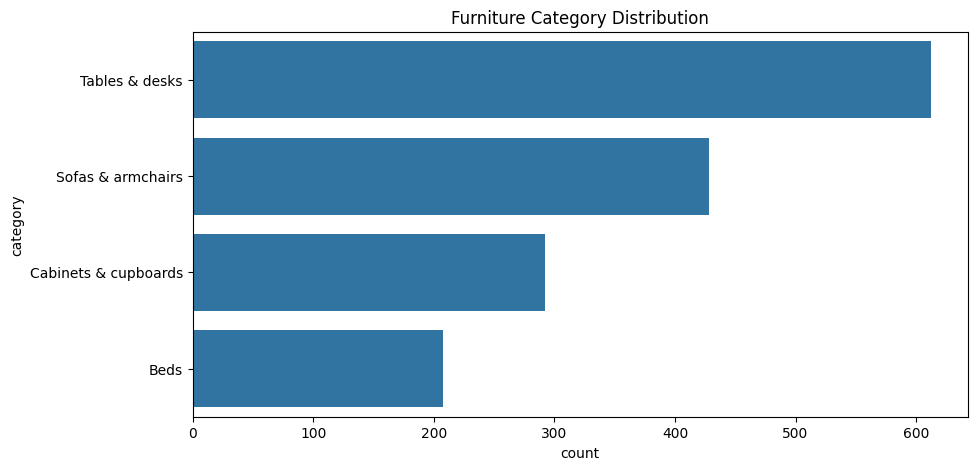

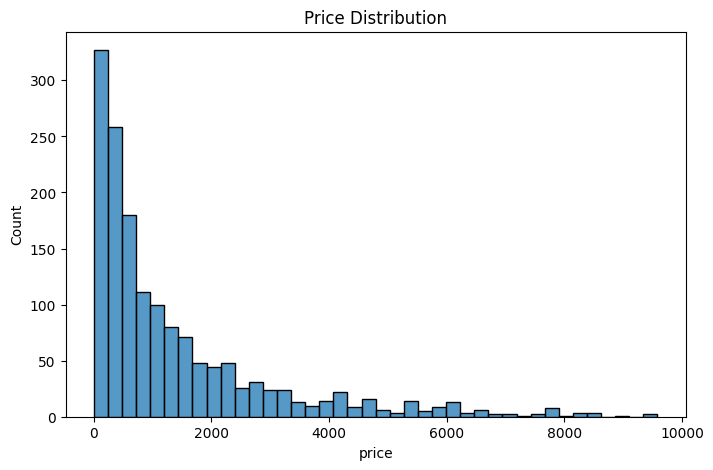

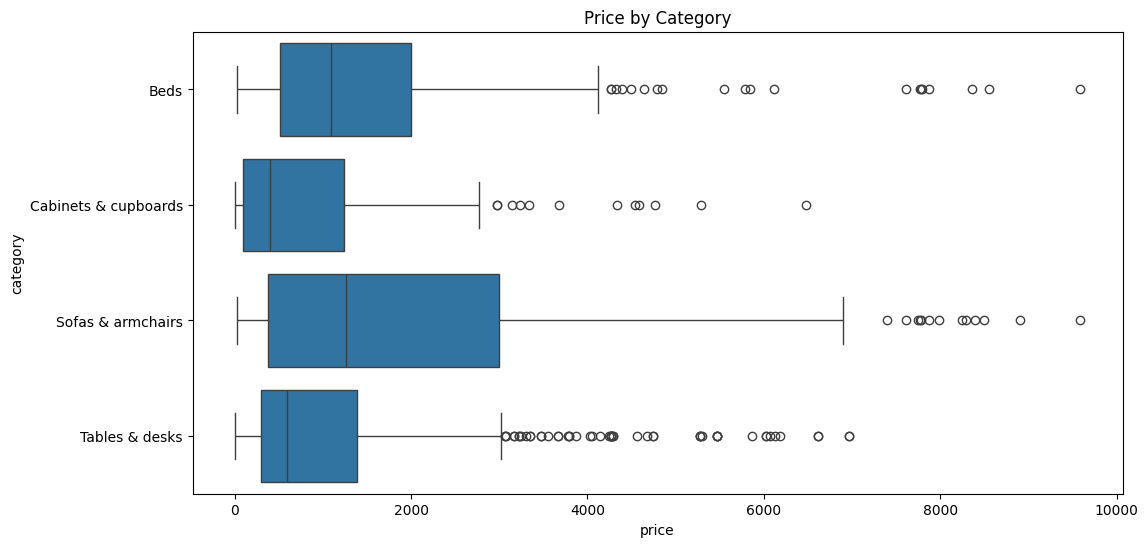

In [7]:
eda.plot_category_distribution(df)

eda.plot_price_distribution(df)

eda.plot_price_by_category(df)

In [8]:
X, y, encoder = data.prepare_ml_data(df)

X_train, X_test, y_train, y_test = data.split_data(
    X,
    y
)

c:\Users\Nomade\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Nomade\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver option

Accuracy: 0.5877

Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.07      0.13        42
           1       0.78      0.48      0.60        58
           2       0.66      0.45      0.54        86
           3       0.53      0.91      0.67       122

    accuracy                           0.59       308
   macro avg       0.64      0.48      0.48       308
weighted avg       0.62      0.59      0.55       308



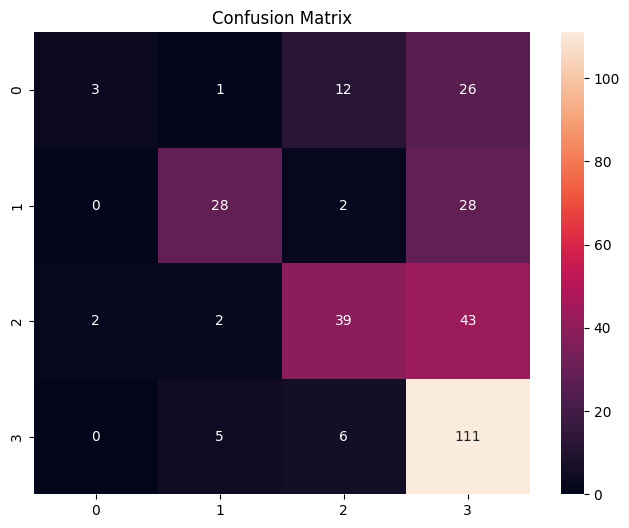

In [9]:
ridge = ml.train_ridge(
    X_train,
    y_train
)

y_pred = eval_ml.evaluate_model(
    ridge,
    X_test,
    y_test
)

eval_ml.plot_confusion_matrix(
    y_test,
    y_pred
)

In [15]:
train_ds, val_ds = dl.load_image_datasets(
    "images/furniture_images"
)

Found 254 files belonging to 4 classes.
Using 204 files for training.
Found 254 files belonging to 4 classes.
Using 50 files for validation.


In [16]:
print(train_ds.class_names)

['Beds', 'Cabinets & cupboards', 'Sofas & armchairs', 'Tables & desks']


In [20]:
import os

base_dir = "images/furniture_images"

for category in os.listdir(base_dir):
    path = os.path.join(base_dir, category)

    if os.path.isdir(path):
        print(
            category,
            len(os.listdir(path))
        )

Beds 61
Cabinets & cupboards 78
Sofas & armchairs 37
Tables & desks 78


In [17]:
model = dl.build_cnn(
    num_classes=4
)

c:\Users\Nomade\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = dl.train_model(
    model,
    train_ds,
    val_ds,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 727ms/step - accuracy: 0.2500 - loss: 1000.3179 - val_accuracy: 0.1000 - val_loss: 14.1361
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 474ms/step - accuracy: 0.2353 - loss: 14.0306 - val_accuracy: 0.4400 - val_loss: 1.7131
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 584ms/step - accuracy: 0.4559 - loss: 1.3738 - val_accuracy: 0.4400 - val_loss: 1.3229
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 639ms/step - accuracy: 0.5539 - loss: 1.1182 - val_accuracy: 0.3800 - val_loss: 1.3093
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 652ms/step - accuracy: 0.5833 - loss: 0.9307 - val_accuracy: 0.4200 - val_loss: 1.2064
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 661ms/step - accuracy: 0.5931 - loss: 1.0031 - val_accuracy: 0.4200 - val_loss: 1.1755
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 648ms/step - accuracy: 0.6078 - loss: 0.9385 - val_accuracy: 0.3800 - val_loss: 3.2377
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 644ms/step - accuracy: 0.6667 - loss: 1.2900 - val_accuracy: 0.5200 - val_

In [66]:
import importlib
importlib.reload(dl)
importlib.reload(eval_dl)
importlib.reload(opti_dl)

<module 'src.opti_dl' from 'c:\\Users\\Nomade\\OneDrive\\Bureau\\DDIA2\\7. Deep Learning\\TP-NueralNetwork\\src\\opti_dl.py'>

In [41]:
dl.save_model(model)

Model saved to models/furniture_cnn.keras


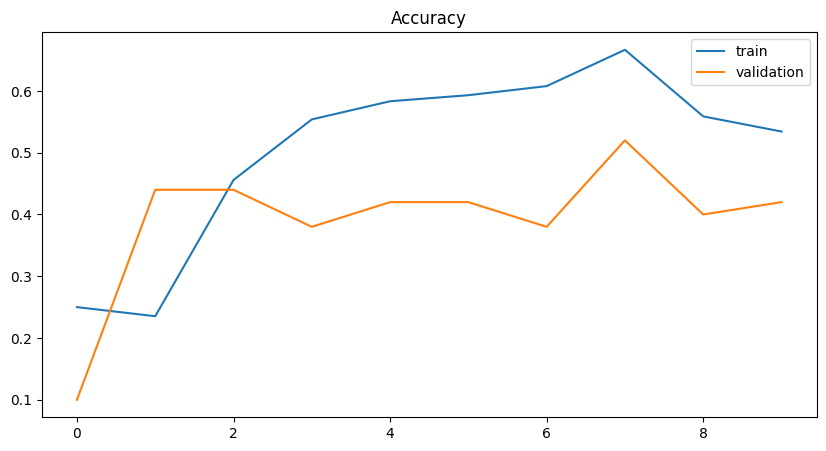

In [44]:
eval_dl.plot_history(history)

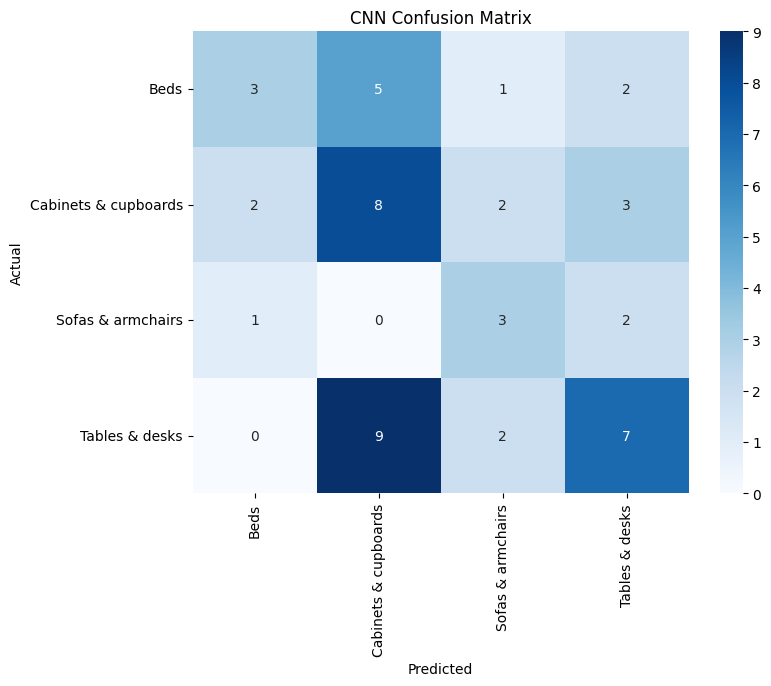

In [47]:
eval_dl.plot_confusion_matrix(
    model,
    val_ds,
    train_ds.class_names
)

In [55]:
mobilenet = opti_dl.build_mobilenet(
    num_classes=4
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [56]:
mobilenet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [57]:
history_mobile = opti_dl.train_mobilenet(
    mobilenet,
    train_ds,
    val_ds,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.3186 - loss: 1.6439 - val_accuracy: 0.4200 - val_loss: 1.3331
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 683ms/step - accuracy: 0.3529 - loss: 1.4732 - val_accuracy: 0.5400 - val_loss: 1.1337
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 671ms/step - accuracy: 0.4461 - loss: 1.3357 - val_accuracy: 0.5800 - val_loss: 1.0815
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 678ms/step - accuracy: 0.4902 - loss: 1.2385 - val_accuracy: 0.6000 - val_loss: 1.0252
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 688ms/step - accuracy: 0.5343 - loss: 1.0915 - val_accuracy: 0.6000 - val_loss: 0.9612
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 683ms/step - accuracy: 0.5735 - loss: 1.0135 - val_accuracy: 0.5600 - val_loss: 0.9103
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 706ms/step - accuracy: 0.6275 - loss: 0.9116 - val_accuracy: 0.6000 - val_loss: 0.8628
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 620ms/step - accuracy: 0.6471 - loss: 0.8368 - val_accuracy: 0.6600 - val_loss: 

In [67]:
opti_dl.save_model(model)

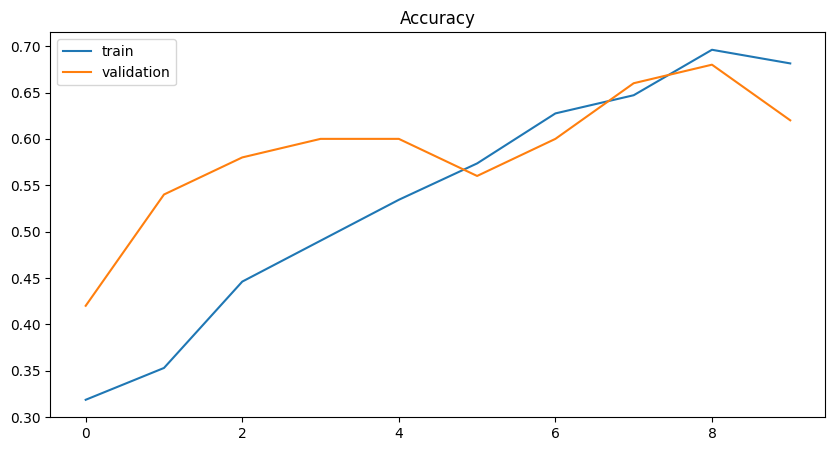

In [64]:
eval_dl.plot_history(
    history_mobile
)

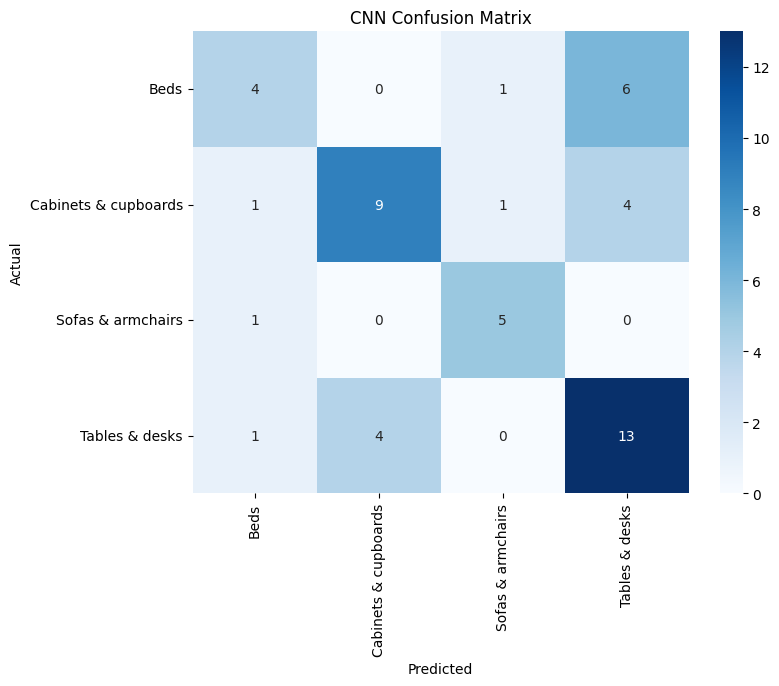

In [65]:
eval_dl.plot_confusion_matrix(
    mobilenet,
    val_ds,
    train_ds.class_names
)